<div style="width:100%; background-color:#181818; color:#f1f1f1; padding:30px 0; text-align:center; border-radius:10px;">

  <img src="https://media4.giphy.com/media/v1.Y2lkPTc5MGI3NjExcXVodWNsM3Bia3duZGljZzRqMTI2MGFiZjlkZzBwcmhuaWxydjlpaiZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/AOSwwqVjNZlDO/giphy.gif" alt="Beam Oscillation" width="600" style="border-radius:10px;">

  <h3 style="color:#ffffff; margin-top:15px;"><b>Solution Example of Truss Element</b></h3>

  <p><b>Author:</b> <a href="http://caceli.net/" style="color:#3ea6ff; text-decoration:none;">Msc. Ing. Carlos Andrés Celi Sánchez</a></p>
  <p><b>Course:</b> Matrix Analisys</p>
  <p><b>Year:</b> MAY - 2026</p>

</div>

#### Libraries

In [33]:
import numpy as np                                                                                                      # Numerical operations and arrays
import pandas as pd                                                                                                     # DataFrame tables for visualization
import matplotlib.pyplot as plt                                                                                         # Plotting tools

from repo_maxtrix_analisys import *                                                                                     # Import package classes and functions

#### Case


#### Data

In [34]:
E = 21000000                                                                                                        # Modulus of elasticity
l = 7                                                                                                               # Base length of the truss panels
li = np.sqrt(l**2 + l**2)
L = [l,l,l,l,l,l,l,l,l,li,li,li,li]                                                                                 # Length of each truss element
thethas = np.zeros(13)                                                                                        # Orientation angle of each element in degrees
thethas[6] = 90
thethas[7] = 90
thethas[8] = 90
thethas[9] = 45
thethas[10] = 45
thethas[11] = 135
thethas[12] = 135
print(f'Thethas = ', thethas)
dv = np.ones(len(thethas)) * 0.032
print(f'dv = ', dv)
A = []
for i in range(len(dv)):
    A.append(np.pi * dv[i]**(2) / 4 )
local_dof = 2                                                                                                       # Local DOF per element
Global_dof = 4                                                                                                      # Global DOF per element
nglt = 16                                                                                                            # Number of global DOF including supports
gdl = 13                                                                                                             # Number of free global DOF          

Lee = np.array([                                                                                                    # Placement vectors of each element
    [1,2,3,4],                                                                                                   # Element 1
    [3,4,5,6],                                                                                                   # Element 2
    [14,15,7,8],                                                                                                   # Element 3
    [7,8,9,10],                                                                                                   # Element 4
    [9,10,11,12],                                                                                                   # Element 5
    [11,12,13,16],                                                                                                   # Element 6
    [7,8,1,2],
    [9,10,3,4],
    [11,12,5,6],
    [14,15,1,2],
    [9,10,5,6],
    [9,10,1,2],
    [13,16,5,6]
])

Lee_Nodos = np.array([                                                                                              # Node connectivity of each element
    [1,2],
    [2,3],
    [4,5],
    [5,6],
    [6,7],
    [7,8],
    [5,1],
    [6,2],
    [7,3],
    [4,1],
    [6,3],
    [6,1],
    [8,3]                          
])
                    
P = np.zeros(gdl)                                                                                                   # Initialize load vector for free global DOF
P[0] = 10
P[1] = -20
P[3] = -40
P[5] = -30
P[7] = -10
P[9] = -50
P[11] = -10
P = np.vstack(P)                                                                                                    # Convert load vector to column format

fyT = 42000
fyC = fyT * 0.6

element_names = [f'Elem_{i+1}' for i in range(len(Lee))]                                                            # Element labels for the table
Lee_table = pd.DataFrame(                                                                                           # Convert placement vectors to DataFrame
    Lee,                                                                                                            # Placement vector array
    index=element_names,                                                                                            # DataFrame row names
    columns=["GDLg_Ax", "GDLg_Ay", "GDLg_Bx", "GDLg_By"]                                                            # Global DOF column names
)
print("=" * 120)                                                                                                    # Print table separator
print('Placement Vectors')                                                                                          # Print table title
print("=" * 120)                                                                                                    # Print table separator
Lee_table                                                                                                           # Display placement vectors table

Thethas =  [  0.   0.   0.   0.   0.   0.  90.  90.  90.  45.  45. 135. 135.]
dv =  [0.032 0.032 0.032 0.032 0.032 0.032 0.032 0.032 0.032 0.032 0.032 0.032
 0.032]
Placement Vectors


,GDLg_Ax,GDLg_Ay,GDLg_Bx,GDLg_By
Elem_1,1,2,3,4
Elem_2,3,4,5,6
Elem_3,14,15,7,8
Elem_4,7,8,9,10
Elem_5,9,10,11,12
Elem_6,11,12,13,16
Elem_7,7,8,1,2
Elem_8,9,10,3,4
Elem_9,11,12,5,6
Elem_10,14,15,1,2


#### Solution

##### Stiffness Matrix in Local Coordinates

In [35]:
# --- Create structure container -----------------------------------------------------------------------------------
structure = Manager_K_T_elements2D(method= 'ARM')                                                                   # Create an instance of the MF structure

# --- Add ARM elements to the structure -----------------------------------------------------------------------------
for i in np.arange(0, len(thethas), 1):                                                                             # Loop to add each element
    structure.add_element(ARM_K_T_Element2D(E = E,A = A[i], L = L[i], thetha= thethas[i]))                             # Add ARM element with its properties   

In [36]:
# --- Stack local stiffness matrices --------------------------------------------------------------------------------
K_all = structure.stacked_stiffness_matrices()                                                                      # Stacked stiffness matrix (2N x 2)

# --- Convert to DataFrame for visualization -----------------------------------------------------------------------
n_elem = len(structure.elements)                                                                                    # Number of elements in the structure
n_dof  = local_dof                                                                                                  # Number of local DOF per element

rows = pd.MultiIndex.from_tuples(                                                                                   # Create hierarchical index for local stiffness matrices
    [(f'Elem_{e+1}', f'DOF_L_{d+1}') for e in range(n_elem) for d in range(n_dof)],                                 # Element and local DOF labels
    names=['Element', 'Local DOF']                                                                                  # Index level names
)

K_all_df = pd.DataFrame(K_all, index=rows, columns=[f'DOF_L_{i}' for i in np.arange(1, K_all.shape[1] + 1)])        # Convert to DataFrame for better visualization
print("=" * 120)                                                                                                    # Print table separator
print('Local Stiffness Matrices')                                                                                   # Print table title
print("=" * 120)                                                                                                    # Print table separator
K_all_df.head(len(K_all_df))                                                                                        # Display stacked matrices 

Local Stiffness Matrices


DOF_L_1      DOF_L_2
Element Local DOF                          
Elem_1  DOF_L_1    2412.743158 -2412.743158
        DOF_L_2   -2412.743158  2412.743158
Elem_2  DOF_L_1    2412.743158 -2412.743158
        DOF_L_2   -2412.743158  2412.743158
Elem_3  DOF_L_1    2412.743158 -2412.743158
        DOF_L_2   -2412.743158  2412.743158
Elem_4  DOF_L_1    2412.743158 -2412.743158
        DOF_L_2   -2412.743158  2412.743158
Elem_5  DOF_L_1    2412.743158 -2412.743158
        DOF_L_2   -2412.743158  2412.743158
Elem_6  DOF_L_1    2412.743158 -2412.743158
        DOF_L_2   -2412.743158  2412.743158
Elem_7  DOF_L_1    2412.743158 -2412.743158
        DOF_L_2   -2412.743158  2412.743158
Elem_8  DOF_L_1    2412.743158 -2412.743158
        DOF_L_2   -2412.743158  2412.743158
Elem_9  DOF_L_1    2412.743158 -2412.743158
        DOF_L_2   -2412.743158  2412.743158
Elem_10 DOF_L_1    1706.067048 -1706.067048
        DOF_L_2   -1706.067048  1706.067048
Elem_11 DOF_L_1    1706.067048 -1706.067048
        DOF_L_2   -1706.067048  1706.067048
Elem_12 DOF_L_1    1706.067048 -1706.067048
        DOF_L_2   -1706.067048  1706.067048
Elem_13 DOF_L_1    1706.067048 -1706.067048
        DOF_L_2   -1706.067048  1706.067048

##### Transformation Matrix

In [37]:
# --- Stack Transformation matrices --------------------------------------------------------------------------------
T_all = structure.stacked_transformation_matrices()                                                                 # Stacked transformation matrix (4N x 2)

# --- Convert to DataFrame for visualization -----------------------------------------------------------------------
n_dof  = Global_dof                                                                                                 # Number of local-global DOF per element
rows = pd.MultiIndex.from_tuples(                                                                                   # Create hierarchical index for transformation matrices
    [(f'Elem_{e+1}', f'DOF_L_G_{d+1}') for e in range(n_elem) for d in range(n_dof)],                               # Element and local-global DOF labels
    names=['Element', 'Local - Global DOF']                                                                         # Index level names
)

T_all_df = pd.DataFrame(T_all, index=rows, columns=['Column 1', 'Column 2'])                                        # Convert to DataFrame for better visualization
print("=" * 120)                                                                                                    # Print table separator
print('Transformation Matrices')                                                                                    # Print table title
print("=" * 120)                                                                                                    # Print table separator
T_all_df.head(len(T_all_df)).round(3)                                                                                        # Display stacked matrices


Transformation Matrices


Column 1  Column 2
Element Local - Global DOF                    
Elem_1  DOF_L_G_1              1.000     0.000
        DOF_L_G_2              0.000     0.000
        DOF_L_G_3              0.000     1.000
        DOF_L_G_4              0.000     0.000
Elem_2  DOF_L_G_1              1.000     0.000
        DOF_L_G_2              0.000     0.000
        DOF_L_G_3              0.000     1.000
        DOF_L_G_4              0.000     0.000
Elem_3  DOF_L_G_1              1.000     0.000
        DOF_L_G_2              0.000     0.000
        DOF_L_G_3              0.000     1.000
        DOF_L_G_4              0.000     0.000
Elem_4  DOF_L_G_1              1.000     0.000
        DOF_L_G_2              0.000     0.000
        DOF_L_G_3              0.000     1.000
        DOF_L_G_4              0.000     0.000
Elem_5  DOF_L_G_1              1.000     0.000
        DOF_L_G_2              0.000     0.000
        DOF_L_G_3              0.000     1.000
        DOF_L_G_4              0.000     0.000
Elem_6  DOF_L_G_1              1.000     0.000
        DOF_L_G_2              0.000     0.000
        DOF_L_G_3              0.000     1.000
        DOF_L_G_4              0.000     0.000
Elem_7  DOF_L_G_1              0.000     0.000
        DOF_L_G_2              1.000     0.000
        DOF_L_G_3              0.000     0.000
        DOF_L_G_4              0.000     1.000
Elem_8  DOF_L_G_1              0.000     0.000
        DOF_L_G_2              1.000     0.000
        DOF_L_G_3              0.000     0.000
        DOF_L_G_4              0.000     1.000
Elem_9  DOF_L_G_1              0.000     0.000
        DOF_L_G_2              1.000     0.000
        DOF_L_G_3              0.000     0.000
        DOF_L_G_4              0.000     1.000
Elem_10 DOF_L_G_1              0.707     0.000
        DOF_L_G_2              0.707     0.000
        DOF_L_G_3              0.000     0.707
        DOF_L_G_4              0.000     0.707
Elem_11 DOF_L_G_1              0.707     0.000
        DOF_L_G_2              0.707     0.000
        DOF_L_G_3              0.000     0.707
        DOF_L_G_4              0.000     0.707
Elem_12 DOF_L_G_1             -0.707     0.000
        DOF_L_G_2              0.707     0.000
        DOF_L_G_3              0.000    -0.707
        DOF_L_G_4              0.000     0.707
Elem_13 DOF_L_G_1             -0.707     0.000
        DOF_L_G_2              0.707     0.000
        DOF_L_G_3              0.000    -0.707
        DOF_L_G_4              0.000     0.707

##### Stiffness Matrix in Global Coordinates

In [38]:
Keg_all = []                                                                                                        # Empty list to store global element stiffness matrices
for i in np.arange(0,n_elem,1):                                                                                     # Loop through each element
    Telem = structure.elements[i].transformation_ARM_matrix_2D()                                                    # Transformation matrix of element i
    Kelem = structure.elements[i].stiffness_matrix_ARM_AE()                                                         # Local stiffness matrix of element i
    Keg_all.append(Telem@Kelem@Telem.T)                                                                             # Transform local stiffness matrix to global coordinates

rows = pd.MultiIndex.from_tuples(                                                                                   # Create hierarchical index for global element matrices
    [
        (f'Elem_{e+1}', f'GDLg_{int(gdl)}')                                                                         # Element and global DOF labels
        for e in range(n_elem)                                                                                      # Loop through each element
        for gdl in Lee[e]                                                                                           # Loop through the placement vector of each element
    ],
    names=['Element', 'Placement Vector']                                                                           # Index level names
)

Keg_stack = np.vstack(Keg_all)                                                                                      # Stack all global element stiffness matrices
Keg_stack_df = pd.DataFrame(Keg_stack, index=rows,columns=[f'GLDg' for i in range(Global_dof)])                     # Convert stacked matrices to DataFrame
print("=" * 120)                                                                                                    # Print table separator
print('Global Stiffness Matrices')                                                                                  # Print table title
print("=" * 120)                                                                                                    # Print table separator
Keg_stack_df.round(3)                                                                                               # Display rounded global element matrices

Global Stiffness Matrices


GLDg      GLDg      GLDg      GLDg
Element Placement Vector                                        
Elem_1  GDLg_1            2412.743     0.000 -2412.743     0.000
        GDLg_2               0.000     0.000     0.000     0.000
        GDLg_3           -2412.743     0.000  2412.743     0.000
        GDLg_4               0.000     0.000     0.000     0.000
Elem_2  GDLg_3            2412.743     0.000 -2412.743     0.000
        GDLg_4               0.000     0.000     0.000     0.000
        GDLg_5           -2412.743     0.000  2412.743     0.000
        GDLg_6               0.000     0.000     0.000     0.000
Elem_3  GDLg_14           2412.743     0.000 -2412.743     0.000
        GDLg_15              0.000     0.000     0.000     0.000
        GDLg_7           -2412.743     0.000  2412.743     0.000
        GDLg_8               0.000     0.000     0.000     0.000
Elem_4  GDLg_7            2412.743     0.000 -2412.743     0.000
        GDLg_8               0.000     0.000     0.000     0.000
        GDLg_9           -2412.743     0.000  2412.743     0.000
        GDLg_10              0.000     0.000     0.000     0.000
Elem_5  GDLg_9            2412.743     0.000 -2412.743     0.000
        GDLg_10              0.000     0.000     0.000     0.000
        GDLg_11          -2412.743     0.000  2412.743     0.000
        GDLg_12              0.000     0.000     0.000     0.000
Elem_6  GDLg_11           2412.743     0.000 -2412.743     0.000
        GDLg_12              0.000     0.000     0.000     0.000
        GDLg_13          -2412.743     0.000  2412.743     0.000
        GDLg_16              0.000     0.000     0.000     0.000
Elem_7  GDLg_7               0.000     0.000    -0.000    -0.000
        GDLg_8               0.000  2412.743    -0.000 -2412.743
        GDLg_1              -0.000    -0.000     0.000     0.000
        GDLg_2              -0.000 -2412.743     0.000  2412.743
Elem_8  GDLg_9               0.000     0.000    -0.000    -0.000
        GDLg_10              0.000  2412.743    -0.000 -2412.743
        GDLg_3              -0.000    -0.000     0.000     0.000
        GDLg_4              -0.000 -2412.743     0.000  2412.743
Elem_9  GDLg_11              0.000     0.000    -0.000    -0.000
        GDLg_12              0.000  2412.743    -0.000 -2412.743
        GDLg_5              -0.000    -0.000     0.000     0.000
        GDLg_6              -0.000 -2412.743     0.000  2412.743
Elem_10 GDLg_14            853.034   853.034  -853.034  -853.034
        GDLg_15            853.034   853.034  -853.034  -853.034
        GDLg_1            -853.034  -853.034   853.034   853.034
        GDLg_2            -853.034  -853.034   853.034   853.034
Elem_11 GDLg_9             853.034   853.034  -853.034  -853.034
        GDLg_10            853.034   853.034  -853.034  -853.034
        GDLg_5            -853.034  -853.034   853.034   853.034
        GDLg_6            -853.034  -853.034   853.034   853.034
Elem_12 GDLg_9             853.034  -853.034  -853.034   853.034
        GDLg_10           -853.034   853.034   853.034  -853.034
        GDLg_1            -853.034   853.034   853.034  -853.034
        GDLg_2             853.034  -853.034  -853.034   853.034
Elem_13 GDLg_13            853.034  -853.034  -853.034   853.034
        GDLg_16           -853.034   853.034   853.034  -853.034
        GDLg_5            -853.034   853.034   853.034  -853.034
        GDLg_6             853.034  -853.034  -853.034   853.034

### Stiffness Matrix of the Structure.

#### Initialize Stiffness Matrix of the Structure

In [39]:
S = np.zeros((nglt, nglt))                                                                                          # Initialize global Structure stiffness matrix
rowsS = pd.Index(f'GDLg_{i+1}' for i in range(nglt))                                                                # Global DOF labels
S_df = pd.DataFrame(S,index= rowsS, columns=[f'GDLg_{i+1}' for i in range(nglt)])                                   # Convert global stiffness matrix to DataFrame
print("=" * 120)                                                                                                    # Print table separator
print('Initialize global Structure stiffness matrix')                                                               # Print table title
print("=" * 120)                                                                                                    # Print table separator
S_df.round(3)                                                                                                       # Display rounded global stiffness matrix

Initialize global Structure stiffness matrix


,GDLg_1,GDLg_2,GDLg_3,GDLg_4,GDLg_5,GDLg_6,GDLg_7,GDLg_8,GDLg_9,GDLg_10,GDLg_11,GDLg_12,GDLg_13,GDLg_14,GDLg_15,GDLg_16
GDLg_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GDLg_10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Assemble Stiffness Matrices of the Structure

In [40]:
for e in range(n_elem):                                                                                             # Loop through each element
    lee = Lee[e]                                                                                                    # Placement vector of element e
    Ke = Keg_all[e]                                                                                                 # Global stiffness matrix of element e
    S_assambler = Assembler(lee = lee, K = Ke, S = S, nglt= nglt)                                                   # Create assembler object for element e
    S = S_assambler.assambler_due_lee()                                                                             # Assemble element stiffness into the global matrix
S_df = pd.DataFrame(S,index= rowsS, columns=[f'GDLg_{i+1}' for i in range(nglt)])                                   # Convert assembled stiffness matrix to DataFrame
print("=" * 120)                                                                                                    # Print table separator
print('Global Structure Stiffness Matrix')                                                                          # Print table title
print("=" * 120)                                                                                                    # Print table separator
S_df.round(3)                                                                                                       # Display rounded assembled stiffness matrix

Global Structure Stiffness Matrix


,GDLg_1,GDLg_2,GDLg_3,GDLg_4,GDLg_5,GDLg_6,GDLg_7,GDLg_8,GDLg_9,GDLg_10,GDLg_11,GDLg_12,GDLg_13,GDLg_14,GDLg_15,GDLg_16
GDLg_1,4118.810,0.000,-2412.743,0.000,0.000,0.000,-0.000,-0.000,-853.034,853.034,0.000,0.000,0.000,-853.034,-853.034,0.000
GDLg_2,0.000,4118.810,0.000,0.000,0.000,0.000,-0.000,-2412.743,853.034,-853.034,0.000,0.000,0.000,-853.034,-853.034,0.000
GDLg_3,-2412.743,0.000,4825.486,0.000,-2412.743,0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,0.000,0.000,0.000,0.000
GDLg_4,0.000,0.000,0.000,2412.743,0.000,0.000,0.000,0.000,-0.000,-2412.743,0.000,0.000,0.000,0.000,0.000,0.000
GDLg_5,0.000,0.000,-2412.743,0.000,4118.810,0.000,0.000,0.000,-853.034,-853.034,-0.000,-0.000,-853.034,0.000,0.000,853.034
GDLg_6,0.000,0.000,0.000,0.000,0.000,4118.810,0.000,0.000,-853.034,-853.034,-0.000,-2412.743,853.034,0.000,0.000,-853.034
GDLg_7,-0.000,-0.000,0.000,0.000,0.000,0.000,4825.486,0.000,-2412.743,0.000,0.000,0.000,0.000,-2412.743,0.000,0.000
GDLg_8,-0.000,-2412.743,0.000,0.000,0.000,0.000,0.000,2412.743,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
GDLg_9,-853.034,853.034,-0.000,-0.000,-853.034,-853.034,-2412.743,0.000,6531.553,0.000,-2412.743,0.000,0.000,0.000,0.000,0.000
GDLg_10,853.034,-853.034,-0.000,-2412.743,-853.034,-853.034,0.000,0.000,0.000,4118.810,0.000,0.000,0.000,0.000,0.000,0.000


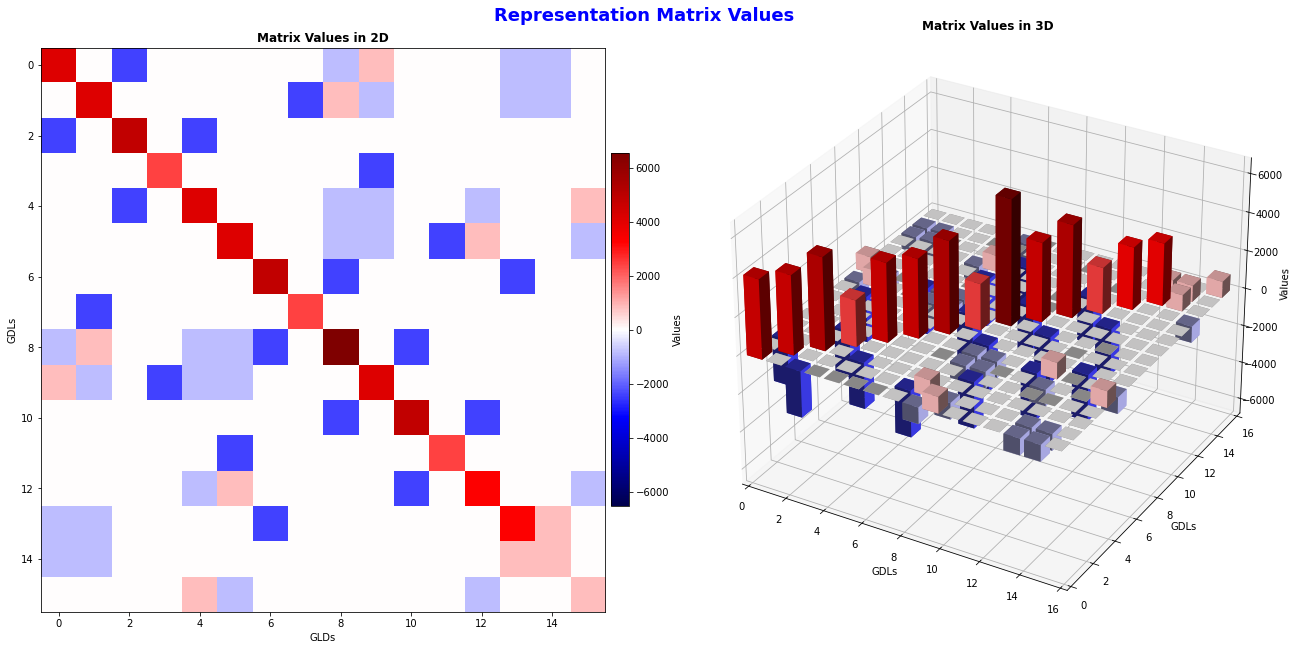

In [41]:
S3d = M_visual_2D_3D(S)                                                                                             # Create 3D visualization object for the global stiffness matrix
S3d.M_visual()                                                                                                      # Display global stiffness matrix as a 3D plot

* SLL

In [42]:
SLL = S[0:gdl,0:gdl]                                                                                                # Extract stiffness submatrix for free global DOF
SLL_df = pd.DataFrame(SLL,index= rowsS[0:gdl], columns=[f'GDLg_{i+1}' for i in range(gdl)])                         # Convert stiffness matrix (SLL) to DataFrame
print("=" * 120)                                                                                                    # Print table separator
print('Global Structure Stiffness Matrix, SLL')                                                                     # Print table title
print("=" * 120)                                                                                                    # Print table separator
SLL_df.round(3)                                                                                                     # Display rounded SLL stiffness matrix

Global Structure Stiffness Matrix, SLL


,GDLg_1,GDLg_2,GDLg_3,GDLg_4,GDLg_5,GDLg_6,GDLg_7,GDLg_8,GDLg_9,GDLg_10,GDLg_11,GDLg_12,GDLg_13
GDLg_1,4118.810,0.000,-2412.743,0.000,0.000,0.000,-0.000,-0.000,-853.034,853.034,0.000,0.000,0.000
GDLg_2,0.000,4118.810,0.000,0.000,0.000,0.000,-0.000,-2412.743,853.034,-853.034,0.000,0.000,0.000
GDLg_3,-2412.743,0.000,4825.486,0.000,-2412.743,0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,0.000
GDLg_4,0.000,0.000,0.000,2412.743,0.000,0.000,0.000,0.000,-0.000,-2412.743,0.000,0.000,0.000
GDLg_5,0.000,0.000,-2412.743,0.000,4118.810,0.000,0.000,0.000,-853.034,-853.034,-0.000,-0.000,-853.034
GDLg_6,0.000,0.000,0.000,0.000,0.000,4118.810,0.000,0.000,-853.034,-853.034,-0.000,-2412.743,853.034
GDLg_7,-0.000,-0.000,0.000,0.000,0.000,0.000,4825.486,0.000,-2412.743,0.000,0.000,0.000,0.000
GDLg_8,-0.000,-2412.743,0.000,0.000,0.000,0.000,0.000,2412.743,0.000,0.000,0.000,0.000,0.000
GDLg_9,-853.034,853.034,-0.000,-0.000,-853.034,-853.034,-2412.743,0.000,6531.553,0.000,-2412.743,0.000,0.000
GDLg_10,853.034,-853.034,-0.000,-2412.743,-853.034,-853.034,0.000,0.000,0.000,4118.810,0.000,0.000,0.000


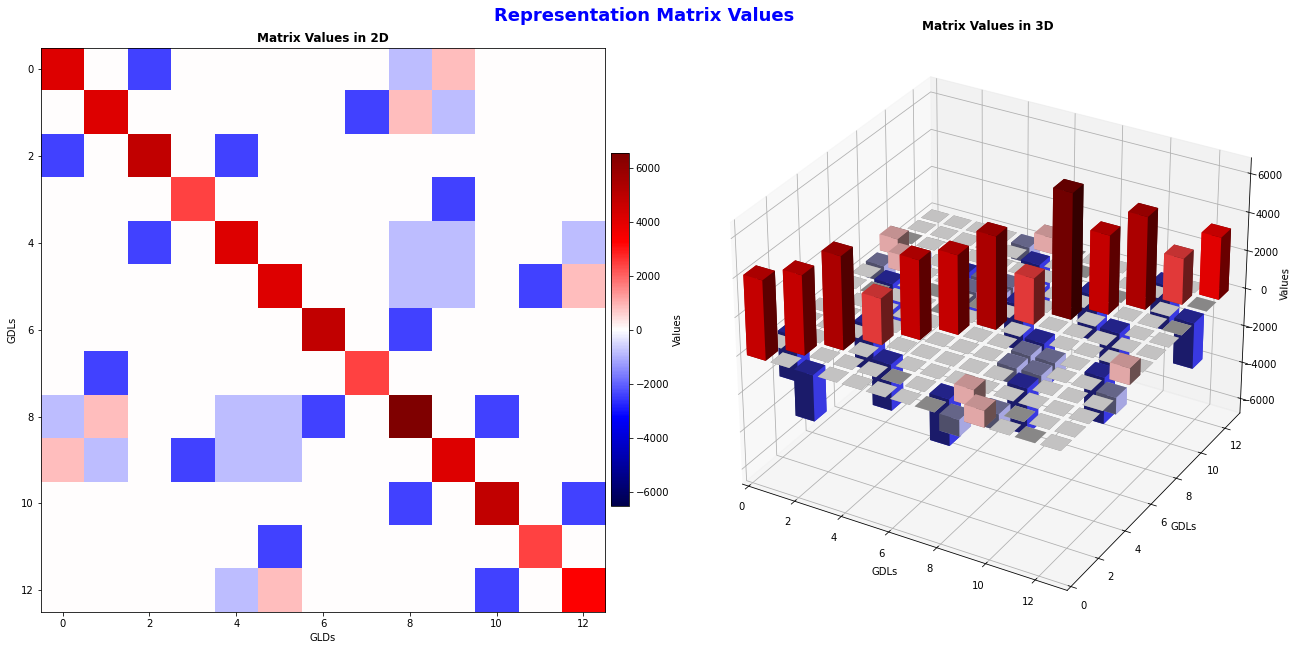

In [43]:
SLL3d = M_visual_2D_3D(SLL)                                                                                         # Create 3D visualization object for the reduced stiffness matrix
SLL3d.M_visual()                                                                                                    # Display reduced stiffness matrix as a 3D plot

### Calculation of Global Displacement.

#### Load Nodal Vector

In [44]:
P_df = pd.DataFrame(P,index= rowsS[0:gdl], columns=['Loads'])                                                       # Convert load vector to DataFrame
print("=" * 120)                                                                                                    # Print table separator
print('Load Nodal Vector [P]')                                                                                      # Print table title
print("=" * 120)                                                                                                    # Print table separator
P_df.round(3)                                                                                                       # Display rounded load vector

Load Nodal Vector [P]


,Loads
GDLg_1,10.0
GDLg_2,-20.0
GDLg_3,0.0
GDLg_4,-40.0
GDLg_5,0.0
GDLg_6,-30.0
GDLg_7,0.0
GDLg_8,-10.0
GDLg_9,0.0
GDLg_10,-50.0


#### Global Displacement Vector

In [45]:
SLL_inv = np.linalg.inv(SLL)                                                                                        # Compute inverse of the reduced stiffness matrix
delta_g = SLL_inv@P                                                                                                 # Solve global free DOF displacements

delta_g_full = np.vstack((delta_g, np.zeros((nglt-gdl, 1))))

delta_g_df = pd.DataFrame(delta_g_full, index = rowsS[:nglt],columns= ['delta_GDL_g [m]'])                                # Convert displacement vector to DataFrame

print("=" * 120)                                                                                                    # Print table separator
print('Global Displacements')                                                                                       # Print table title
print("=" * 120)                                                                                                    # Print table separator
delta_g_df.round(10)                                                                                                # Display rounded displacement vector
delta_g_df                                                                                                          # Display global displacement vector

Global Displacements


,delta_GDL_g [m]
GDLg_1,0.127271
GDLg_2,-0.215192
GDLg_3,0.073390
GDLg_4,-0.341335
GDLg_5,0.019509
GDLg_6,-0.221053
GDLg_7,0.035230
GDLg_8,-0.219337
GDLg_9,0.070459
GDLg_10,-0.324756


#### Plot Displacement

elem_1, nodo i = 1 to node j = 2
elem_2, nodo i = 2 to node j = 3
elem_3, nodo i = 4 to node j = 5
elem_4, nodo i = 5 to node j = 6
elem_5, nodo i = 6 to node j = 7
elem_6, nodo i = 7 to node j = 8
elem_7, nodo i = 5 to node j = 1
elem_8, nodo i = 6 to node j = 2
elem_9, nodo i = 7 to node j = 3
elem_10, nodo i = 4 to node j = 1
elem_11, nodo i = 6 to node j = 3
elem_12, nodo i = 6 to node j = 1
elem_13, nodo i = 8 to node j = 3


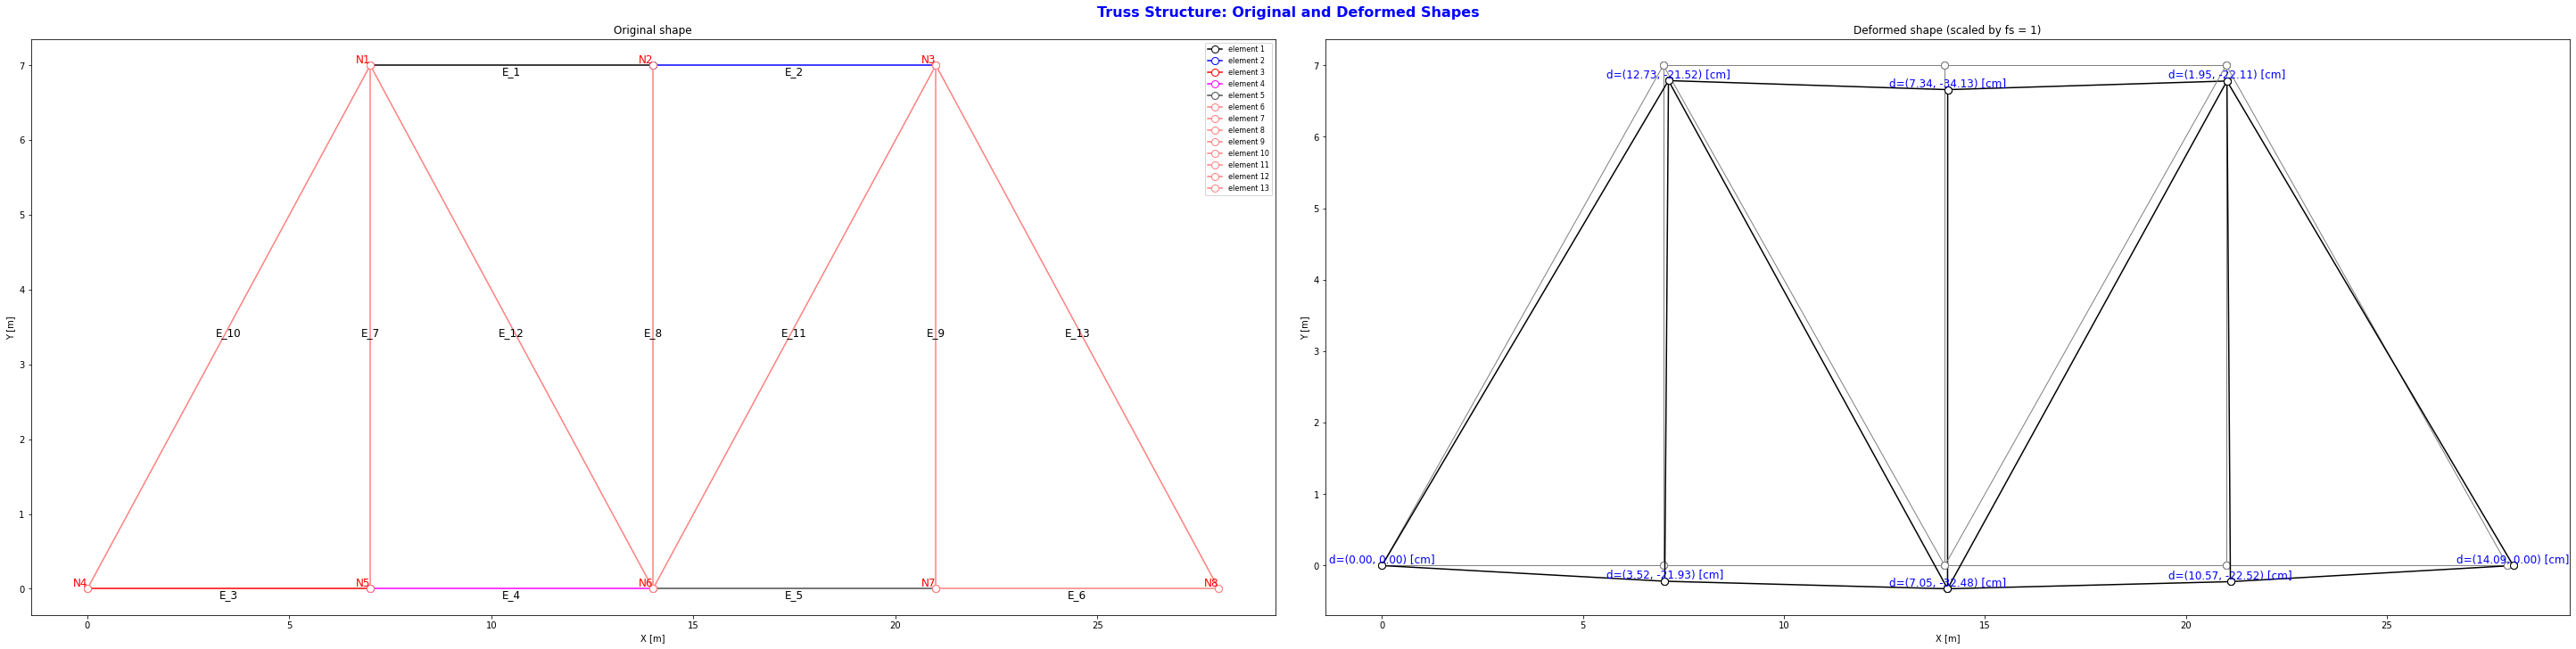

In [46]:
fs = 1                                                                                                             # Scale factor for visualizing displacements in the plot 

delta_g_values = np.asarray(delta_g_full, dtype=float).ravel()                                                           # Convert displacement vector to a flat NumPy array

CoordNode = np.array([                                                                                              # Node coordinates and nodal displacements
    [l, l, delta_g_values[0], delta_g_values[1]],                                                                                                   # Node 1: (x, y, delta_x, delta_y)
    [2*l,l,delta_g_values[2], delta_g_values[3]],
    [3*l,l,delta_g_values[4], delta_g_values[5]],
    [0,0,delta_g_values[13], delta_g_values[14]],
    [l,0,delta_g_values[6], delta_g_values[7]],
    [2*l,0,delta_g_values[8], delta_g_values[9]],
    [3*l,0,delta_g_values[10], delta_g_values[11]],
    [4*l,0,delta_g_values[12], delta_g_values[15]]
])

colors = [                                                                                                          # Element colors used in the original shape plot
    (0, 0, 0),                                                                                                      # Element 1 color
    (0, 0, 1),                                                                                                      # Element 2 color
    (1, 0, 0),                                                                                                      # Element 3 color
    (1, 0, 1),                                                                                                      # Element 4 color
    (0.3, 0.3, 0.3),                                                                                                # Element 5 color
    (1, 0.5, 0.5),                                                                                                   # Element 6 color
    (1, 0.5, 0.5),
    (1, 0.5, 0.5),
    (1, 0.5, 0.5),
    (1, 0.5, 0.5),
    (1, 0.5, 0.5),
    (1, 0.5, 0.5),
    (1, 0.5, 0.5)
]

fig, ax = plt.subplots(1, 2, figsize=(40, 10), constrained_layout=True)                                             # Create two side-by-side subplots
fig.suptitle('Truss Structure: Original and Deformed Shapes', fontsize=16, fontweight='bold', color=(0,0,1))        # Set figure title

for e, (n1, n2) in enumerate(Lee_Nodos):                                                                            # Loop through each element connectivity row
    i = n1 - 1                                                                                                      # Convert initial node number to Python index
    j = n2 - 1                                                                                                      # Convert final node number to Python index
    
    print(f'elem_{e+1}, nodo i = {i+1} to node j = {j+1}')                                                          # Print element connectivity check
    
    x = [CoordNode[i, 0], CoordNode[j, 0]]                                                                          # Original x-coordinates of the element
    y = [CoordNode[i, 1], CoordNode[j, 1]]                                                                          # Original y-coordinates of the element
    
    x_def = [                                                                                                       # Deformed x-coordinates of the element
        CoordNode[i, 0] + CoordNode[i, 2] * fs,                                                                     # Deformed x-coordinate of initial node
        CoordNode[j, 0] + CoordNode[j, 2] * fs                                                                      # Deformed x-coordinate of final node
    ]

    y_def = [                                                                                                       # Deformed y-coordinates of the element
        CoordNode[i, 1] + CoordNode[i, 3] * fs,                                                                     # Deformed y-coordinate of initial node
        CoordNode[j, 1] + CoordNode[j, 3] * fs                                                                      # Deformed y-coordinate of final node
    ]

    ax[0].plot(x, y, color=colors[e],lw=1.5,ls='-',marker='o', markersize=8, markerfacecolor=(1, 1, 1),label=f'element {e + 1}') # Plot original element
    ax[0].set_title('Original shape')                                                                               # Set title for original shape subplot
    ax[0].text((x[0] + x[1]) / 2, (y[0] + y[1]) / 2, f'E_{e+1}', fontsize=12, ha='center', va='top', color=(0,0,0)) # Add element label at midpoint


    ax[1].plot(x, y, color=(0.5,0.5,0.5),lw=1,ls='-',marker='o', markersize=8, markerfacecolor=(1, 1, 1))           # Plot original element as reference
    ax[1].plot(x_def, y_def, color=(0,0,0),lw=1.5,ls='-',marker='o', markersize=8, markerfacecolor=(1, 1, 1))       # Plot deformed element
    ax[1].set_title(f'Deformed shape (scaled by fs = {fs})')                                                        # Set title for deformed shape subplot

for n in range(len(CoordNode)):                                                                                     # Loop through each node
    ax[0].text(CoordNode[n, 0],CoordNode[n, 1],f'N{n+1}',fontsize=12,ha='right',va='bottom',color=(1,0,0))          # Add node label to original shape
    x_node_def = CoordNode[n, 0] + CoordNode[n, 2] * fs                                                              # Deformed x-coordinate of node n
    y_node_def = CoordNode[n, 1] + CoordNode[n, 3] * fs                                                              # Deformed y-coordinate of node n
    ax[1].text(x_node_def, y_node_def, f'd=({CoordNode[n, 2]*100:.2f}, {CoordNode[n, 3]*100:.2f}) [cm]', fontsize=12, ha='center', va='bottom', color=(0,0,1)) # Add nodal displacement over deformed node
    
for a in ax:                                                                                                        # Loop through both subplots
    # a.set_xlim(-0.2 * l, l + 0.2 * l)                                                                               # Set x-axis limits with margin
    # a.set_ylim(-0.2 * l, l + 0.2 * l)                                                                               # Set y-axis limits with margin
    # a.set_aspect('equal', adjustable='box')                                                                         # Keep equal scale in both axes
    a.set_xlabel('X [m]')                                                                                           # Set x-axis label
    a.set_ylabel('Y [m]')                                                                                           # Set y-axis label
    

ax[0].legend(loc='upper right', fontsize=8, frameon=True)                                                           # Add legend only to original shape subplot

plt.show()                                                                                                          # Display figure

#### Global Displacement for each Element

In [47]:
delta_g_full = np.vstack((delta_g, np.zeros((nglt-gdl, 1))))
Delta_g_elem = []

LeeE = Lee - 1

for e in np.arange(0,len(Lee),1):
    Delta_g_elem.append(delta_g_full[LeeE[e]])

Delta_g_elem = np.vstack(Delta_g_elem)


rows = pd.MultiIndex.from_tuples(                                                                                   # Create hierarchical index for global element matrices
    [
        (f'Elem_{e+1}', f'GDLg_{int(gdl)}')                                                                         # Element and global DOF labels
        for e in range(n_elem)                                                                                      # Loop through each element
        for gdl in Lee[e]                                                                                           # Loop through the placement vector of each element
    ],
    names=['Element', 'Placement Vector']                                                                           # Index level names
)


Delta_g_elem_df = pd.DataFrame(Delta_g_elem,index = rows,columns= ['Global Displacement for each Element'])
Delta_g_elem_df.round(6)

Global Displacement for each Element
Element Placement Vector                                      
Elem_1  GDLg_1                                        0.127271
        GDLg_2                                       -0.215192
        GDLg_3                                        0.073390
        GDLg_4                                       -0.341335
Elem_2  GDLg_3                                        0.073390
        GDLg_4                                       -0.341335
        GDLg_5                                        0.019509
        GDLg_6                                       -0.221053
Elem_3  GDLg_14                                       0.000000
        GDLg_15                                       0.000000
        GDLg_7                                        0.035230
        GDLg_8                                       -0.219337
Elem_4  GDLg_7                                        0.035230
        GDLg_8                                       -0.219337
        GDLg_9                                        0.070459
        GDLg_10                                      -0.324756
Elem_5  GDLg_9                                        0.070459
        GDLg_10                                      -0.324756
        GDLg_11                                       0.105689
        GDLg_12                                      -0.225198
Elem_6  GDLg_11                                       0.105689
        GDLg_12                                      -0.225198
        GDLg_13                                       0.140918
        GDLg_16                                       0.000000
Elem_7  GDLg_7                                        0.035230
        GDLg_8                                       -0.219337
        GDLg_1                                        0.127271
        GDLg_2                                       -0.215192
Elem_8  GDLg_9                                        0.070459
        GDLg_10                                      -0.324756
        GDLg_3                                        0.073390
        GDLg_4                                       -0.341335
Elem_9  GDLg_11                                       0.105689
        GDLg_12                                      -0.225198
        GDLg_5                                        0.019509
        GDLg_6                                       -0.221053
Elem_10 GDLg_14                                       0.000000
        GDLg_15                                       0.000000
        GDLg_1                                        0.127271
        GDLg_2                                       -0.215192
Elem_11 GDLg_9                                        0.070459
        GDLg_10                                      -0.324756
        GDLg_5                                        0.019509
        GDLg_6                                       -0.221053
Elem_12 GDLg_9                                        0.070459
        GDLg_10                                      -0.324756
        GDLg_1                                        0.127271
        GDLg_2                                       -0.215192
Elem_13 GDLg_13                                       0.140918
        GDLg_16                                       0.000000
        GDLg_5                                        0.019509
        GDLg_6                                       -0.221053

#### Local Displacement and Action Member in Local Cordinates for each Element

In [48]:
Delta_L_elem_all = []                                                                                              # Empty list to store local displacement vectors
New_L_elem = []                                                                                                    # Empty list to store current element lengths
New_L_elem_rows = []                                                                                               # Current lengths repeated for each local DOF row
MENSAJE = []
MENSAJE_rows = []
CA = []
CA_rows = []

AmL = []

MENSAJE2 = []
MENSAJE2_rows = []

for e in np.arange(0, n_elem, 1):                                                                                   # Loop through each element
# for e in np.arange(2):
    Telem = structure.elements[e].transformation_ARM_matrix_2D()                                                    # Local-to-global transformation matrix
    Delta_g_elem_e = delta_g_full[LeeE[e]]                                                                          # Global displacement vector of element e
    Delta_L_elem_e = Telem.T @ Delta_g_elem_e                                                                       # Transform global displacements to local coordinates
    
    #-------- Action Members --------
    aml = structure.elements[e].stiffness_matrix_ARM_AE() @ Delta_L_elem_e
    L_actual = L[e] + Delta_L_elem_e[1, 0] - Delta_L_elem_e[0, 0]                                                   # Current length: L + u_local_j - u_local_i

    if L_actual >= L[e]:
        mensaje = 'Traction'
        #--------- Capacity ----------
        ca = fyT * (np.pi * dv[e]**(2) / 4)
    else:
        mensaje = 'Compresion'
        ca = fyC * (np.pi * dv[e]**(2) / 4)
    
    if np.abs(aml[0] / ca) >= 1:
        mensaje2 = 'mal'
    else:
        mensaje2 = 'ok'
    
    MENSAJE2.append(mensaje2)
    MENSAJE2_rows.extend([mensaje2] * local_dof)
    
    Delta_L_elem_all.append(Delta_L_elem_e)                                                                         # Store local displacement vector
    
    AmL.append(aml)
    
    New_L_elem.append(L_actual)                                                                                     # Store one current length per element
    New_L_elem_rows.extend([L_actual] * local_dof)                                                                  # Repeat current length for the DataFrame rows
    
    CA.append(ca)
    CA_rows.extend([ca] * local_dof)
    
    
    MENSAJE.append(mensaje)
    MENSAJE_rows.extend([mensaje] * local_dof)

Delta_L_elem_all = np.vstack(Delta_L_elem_all)                                                                      # Stack local displacement vectors
AmL = np.vstack(AmL)

DCR = np.abs(AmL.ravel() / CA_rows)

rows_L = pd.MultiIndex.from_tuples(                                                                                 # Create hierarchical index for local displacement vectors
    [
        (f'Elem_{e+1}', f'DOF_L_{d+1}')                                                                             # Element and local DOF labels
        for e in range(n_elem)                                                                                      # Loop through each element
        for d in range(local_dof)                                                                                   # Loop through local DOF
    ],
    names=['Element', 'Local DOF']                                                                                  # Index level names
)

Delta_L_elem_all_df = pd.DataFrame(                                                                                 # Convert local displacements and lengths to DataFrame
    {
        'Local Displacement for each Element [m]': Delta_L_elem_all.ravel(),
        'Current Length [m]': New_L_elem_rows,
        'Message ':MENSAJE_rows,
        'Action Members [T]': AmL.ravel(),
        'Capacity [T]': CA_rows,
        'DCR': DCR,
        'Revision': MENSAJE2_rows,       
    },
    index=rows_L
)
Delta_L_elem_all_df.round(6)

Local Displacement for each Element [m]  \
Element Local DOF                                            
Elem_1  DOF_L_1                                   0.127271   
        DOF_L_2                                   0.073390   
Elem_2  DOF_L_1                                   0.073390   
        DOF_L_2                                   0.019509   
Elem_3  DOF_L_1                                   0.000000   
        DOF_L_2                                   0.035230   
Elem_4  DOF_L_1                                   0.035230   
        DOF_L_2                                   0.070459   
Elem_5  DOF_L_1                                   0.070459   
        DOF_L_2                                   0.105689   
Elem_6  DOF_L_1                                   0.105689   
        DOF_L_2                                   0.140918   
Elem_7  DOF_L_1                                  -0.219337   
        DOF_L_2                                  -0.215192   
Elem_8  DOF_L_1                                  -0.324756   
        DOF_L_2                                  -0.341335   
Elem_9  DOF_L_1                                  -0.225198   
        DOF_L_2                                  -0.221053   
Elem_10 DOF_L_1                                   0.000000   
        DOF_L_2                                  -0.062170   
Elem_11 DOF_L_1                                  -0.179815   
        DOF_L_2                                  -0.142513   
Elem_12 DOF_L_1                                  -0.279460   
        DOF_L_2                                  -0.242158   
Elem_13 DOF_L_1                                  -0.099644   
        DOF_L_2                                  -0.170104   

                   Current Length [m]    Message   Action Members [T]  \
Element Local DOF                                                       
Elem_1  DOF_L_1              6.946119  Compresion          130.000000   
        DOF_L_2              6.946119  Compresion         -130.000000   
Elem_2  DOF_L_1              6.946119  Compresion          130.000000   
        DOF_L_2              6.946119  Compresion         -130.000000   
Elem_3  DOF_L_1              7.035230    Traction          -85.000000   
        DOF_L_2              7.035230    Traction           85.000000   
Elem_4  DOF_L_1              7.035230    Traction          -85.000000   
        DOF_L_2              7.035230    Traction           85.000000   
Elem_5  DOF_L_1              7.035230    Traction          -85.000000   
        DOF_L_2              7.035230    Traction           85.000000   
Elem_6  DOF_L_1              7.035230    Traction          -85.000000   
        DOF_L_2              7.035230    Traction           85.000000   
Elem_7  DOF_L_1              7.004145    Traction          -10.000000   
        DOF_L_2              7.004145    Traction           10.000000   
Elem_8  DOF_L_1              6.983421  Compresion           40.000000   
        DOF_L_2              6.983421  Compresion          -40.000000   
Elem_9  DOF_L_1              7.004145    Traction          -10.000000   
        DOF_L_2              7.004145    Traction           10.000000   
Elem_10 DOF_L_1              9.837325  Compresion          106.066017   
        DOF_L_2              9.837325  Compresion         -106.066017   
Elem_11 DOF_L_1              9.936797    Traction          -63.639610   
        DOF_L_2              9.936797    Traction           63.639610   
Elem_12 DOF_L_1              9.936797    Traction          -63.639610   
        DOF_L_2              9.936797    Traction           63.639610   
Elem_13 DOF_L_1              9.829036  Compresion          120.208153   
        DOF_L_2              9.829036  Compresion         -120.208153   

                   Capacity [T]       DCR Revision  
Element Local DOF                                   
Elem_1  DOF_L_1       20.267043  6.414355      mal  
        DOF_L_2       20.267043  6.414355      mal  
Elem_2  DOF_L_1       20.